# PA Fracking Water Source Analysis
Volume attribution by source type, NHD feature, and geography.
Input: `data/junction_dep_updated.parquet` (49K well→source rows with NHD linkage and DEP reclassification).

In [1]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

SKINNY_PATH = r'G:\My Drive\production\repos\openFF_data_2026_04_03\skinny_df.parquet'

jct = pd.read_parquet('data/junction_dep_updated.parquet')
print(f'Junction rows: {len(jct):,}')
print(f'Unique wells:  {jct["api10"].nunique():,}')
print(f'Unique sources: {jct["planSource"].nunique():,}')
print(f'Total volume:  {jct["volume"].sum()/1e9:.2f} billion gallons')
print()
print('Columns:', list(jct.columns))

Junction rows: 49,363
Unique wells:  5,356
Unique sources: 3,757
Total volume:  99.65 billion gallons

Columns: ['api10', 'operator', 'planSource', 'managementPlanId', 'volume', 'saved_fn', 'operator_clean', 'site_clean', 'site_ID', 'source_type', 'search_name', 'nhd_id', 'nhd_name', 'nhd_ftype', 'nhd_layer', 'score', 'dist_km', 'match_tier', 'dep_score', 'dep_type', 'dep_lat', 'dep_lon', 'dep_src', 'dep_stype']


## 1. Volume by source type

Volume by source type:
                 records  volume_Mgal  pct_vol
source_type                                   
surface_direct     17387      54187.1     54.4
impoundment         9313      17441.4     17.5
srbc_only            488        370.4      0.4
reuse               3083       3092.8      3.1
interconnection     7187      21771.4     21.8
groundwater         2869       2531.0      2.5
ambiguous            388        153.7      0.2
no_source             17        102.9      0.1


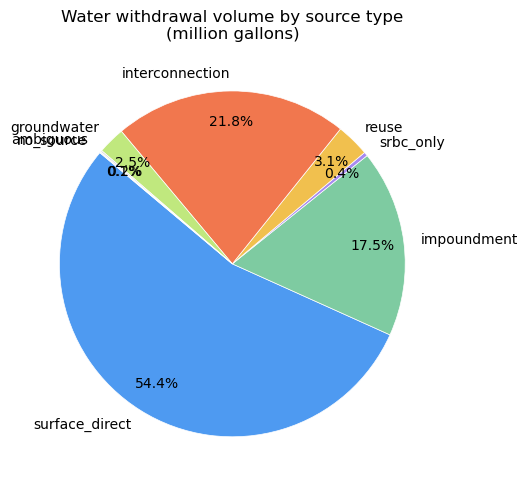

In [2]:
TYPE_ORDER = ['surface_direct','impoundment','srbc_only',
              'reuse','interconnection','groundwater',
              'ambiguous','no_source']

by_type = (
    jct.groupby('source_type')['volume']
    .agg(records='count', volume_gal='sum')
    .assign(
        volume_Mgal = lambda d: (d['volume_gal'] / 1e6).round(1),
        pct_vol     = lambda d: (d['volume_gal'] / d['volume_gal'].sum() * 100).round(1),
    )
    .reindex([t for t in TYPE_ORDER if t in jct['source_type'].unique()])
)
print('Volume by source type:')
print(by_type[['records','volume_Mgal','pct_vol']].to_string())

# Pie chart
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#4e9af1','#7ecba1','#a78af1','#f1c04e','#f1774e','#c0e87e','#ddd','#eee']
by_type['volume_Mgal'].plot.pie(
    ax=ax, autopct='%1.1f%%', startangle=140,
    colors=colors[:len(by_type)], pctdistance=0.82,
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'}
)
ax.set_ylabel('')
ax.set_title('Water withdrawal volume by source type\n(million gallons)')
plt.tight_layout()
plt.savefig('figures/vol_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. NHD match quality by volume

In [3]:
TIER_ORDER = ['high (>=90)', 'good (80-89)', 'fair (60-79)', 'low (<60)', 'unmatched']

def vol_table(df, label=''):
    tbl = (
        df.groupby('match_tier')['volume']
        .agg(records='count', volume_gal='sum')
        .assign(
            volume_Mgal = lambda d: (d['volume_gal'] / 1e6).round(1),
            pct_volume  = lambda d: (d['volume_gal'] / d['volume_gal'].sum() * 100).round(1),
        )
        .reindex(TIER_ORDER)
        [['records', 'volume_Mgal', 'pct_volume']]
    )
    if label:
        print(f'=== {label} ===')
    print(tbl.to_string())
    print()
    return tbl

vol_table(jct, 'All junction rows')

cands = jct[jct['source_type'].isin(['surface_direct','impoundment','srbc_only'])]
vol_table(cands, 'Surface / impoundment / SRBC candidates only')

=== All junction rows ===
              records  volume_Mgal  pct_volume
match_tier                                    
high (>=90)     16320      40405.3        40.5
good (80-89)      323       1075.3         1.1
fair (60-79)     1866       6058.0         6.1
low (<60)          86        364.7         0.4
unmatched       22137      51747.3        51.9

=== Surface / impoundment / SRBC candidates only ===
              records  volume_Mgal  pct_volume
match_tier                                    
high (>=90)     16320      40405.3        56.1
good (80-89)      323       1075.3         1.5
fair (60-79)     1837       6057.3         8.4
low (<60)          86        364.7         0.5
unmatched        8622      24096.1        33.5



,records,volume_Mgal,pct_volume
match_tier,,,
high (>=90),16320,40405.3,56.1
good (80-89),323,1075.3,1.5
fair (60-79),1837,6057.3,8.4
low (<60),86,364.7,0.5
unmatched,8622,24096.1,33.5


## 3. Top NHD-linked surface water features by volume

In [4]:
# High+good confidence matches only
linked = jct[
    jct['match_tier'].isin(['high (>=90)', 'good (80-89)']) &
    jct['nhd_name'].notna()
].copy()

top_features = (
    linked.groupby(['nhd_id', 'nhd_name', 'nhd_ftype', 'nhd_layer'])['volume']
    .agg(wells='count', volume_gal='sum')
    .assign(volume_Mgal=lambda d: (d['volume_gal'] / 1e6).round(1))
    .sort_values('volume_gal', ascending=False)
    .reset_index()
)

print(f'Unique NHD features with high/good matches: {len(top_features):,}')
print(f'Total volume in high/good matches: {top_features["volume_Mgal"].sum():,.0f} Mgal')
print()
print('Top 30 NHD features by withdrawal volume:')
print(top_features[['nhd_name','nhd_ftype','nhd_layer','wells','volume_Mgal']]
      .head(30).to_string(index=False))

Unique NHD features with high/good matches: 133
Total volume in high/good matches: 41,481 Mgal

Top 30 NHD features by withdrawal volume:
                   nhd_name  nhd_ftype nhd_layer  wells  volume_Mgal
          Tunkhannock Creek      460.0  flowline   3717       3897.9
            Allegheny River      558.0  flowline    237       3536.0
            Meshoppen Creek      558.0  flowline   2729       2931.8
                 Ohio River      558.0  flowline    562       2739.3
          Susquehanna River      558.0  flowline   1586       2452.3
          Monongahela River      558.0  flowline    372       1768.3
             Lycoming Creek      558.0  flowline    199       1492.7
                 Ohio River      558.0  flowline    183       1413.8
            Allegheny River      558.0  flowline    119       1205.8
              Martins Creek      460.0  flowline   1246        906.9
East Branch Wyalusing Creek      460.0  flowline    546        903.3
            Loyalsock Creek      5

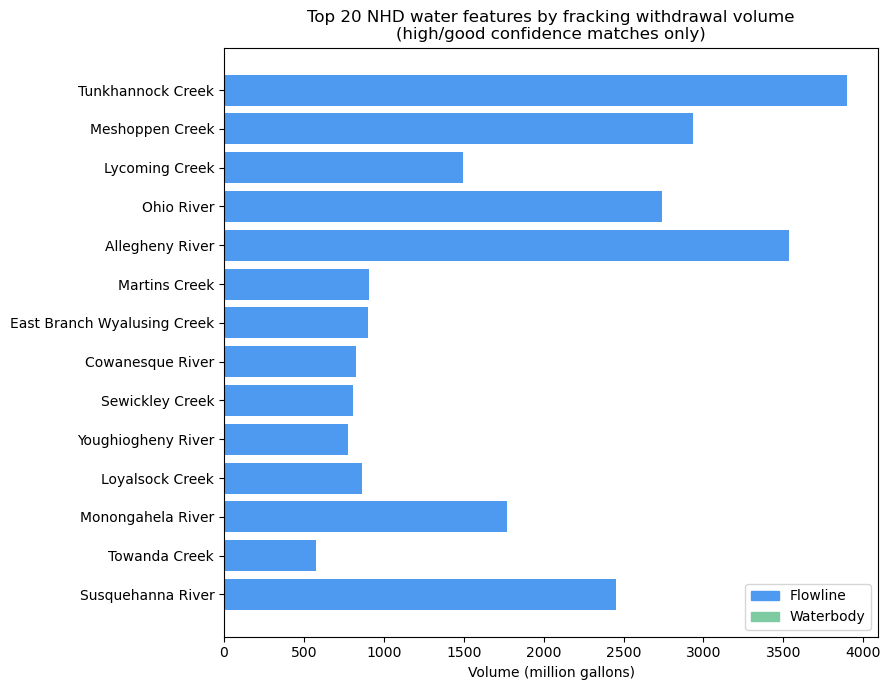

In [5]:
# Bar chart: top 20 features
top20 = top_features.head(20).copy()
top20['label'] = top20['nhd_name'].str[:35]

fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = ['#4e9af1' if r == 'flowline' else '#7ecba1'
              for r in top20['nhd_layer']]
ax.barh(top20['label'][::-1], top20['volume_Mgal'][::-1], color=bar_colors[::-1])
ax.set_xlabel('Volume (million gallons)')
ax.set_title('Top 20 NHD water features by fracking withdrawal volume\n(high/good confidence matches only)')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4e9af1', label='Flowline'),
    Patch(color='#7ecba1', label='Waterbody'),
], loc='lower right')
plt.tight_layout()
plt.savefig('figures/top_nhd_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Temporal trends — volume by year and source type

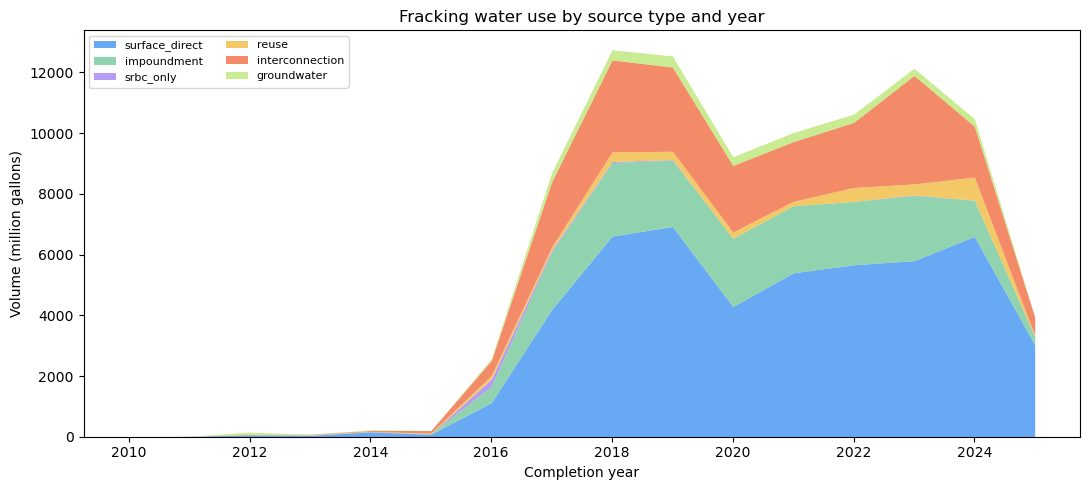

Annual totals (Mgal):
source_type    total  surface_direct  impoundment  srbc_only  reuse  interconnection  groundwater
year                                                                                             
2010.0           0.0             0.0          0.0        0.0    0.0              0.0          0.0
2011.0          15.0            11.0          4.0        0.0    0.0              0.0          0.0
2012.0         154.0            62.0          4.0        0.0    0.0             13.0         75.0
2013.0          83.0            46.0         18.0        0.0    7.0             12.0          0.0
2014.0         228.0           158.0          8.0        8.0    2.0             29.0         23.0
2015.0         205.0            82.0         18.0        0.0   16.0             88.0          1.0
2016.0        2572.0          1123.0        540.0      231.0  125.0            495.0         58.0
2017.0        8697.0          4189.0       1897.0       59.0  105.0           2148.0        300.

In [6]:
# Join completion year from skinny_df
skinny = pd.read_parquet(
    SKINNY_PATH,
    columns=['api10', 'date']
).drop_duplicates('api10')
skinny['year'] = pd.to_datetime(skinny['date'], errors='coerce').dt.year

jct_yr = jct.merge(skinny[['api10','year']], on='api10', how='left')
valid_yr = jct_yr[jct_yr['year'].between(2008, 2025)].copy()

pivot = (
    valid_yr.groupby(['year','source_type'])['volume']
    .sum()
    .unstack('source_type', fill_value=0)
    / 1e6
)

# Keep major types
plot_types = [t for t in TYPE_ORDER if t in pivot.columns
              and t not in ('no_source', 'ambiguous')]
pivot = pivot[plot_types]

type_colors = {
    'surface_direct':  '#4e9af1',
    'impoundment':     '#7ecba1',
    'srbc_only':       '#a78af1',
    'reuse':           '#f1c04e',
    'interconnection': '#f1774e',
    'groundwater':     '#c0e87e',
}

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot.area(ax=ax, color=[type_colors.get(t,'#ccc') for t in pivot.columns],
                linewidth=0, alpha=0.85)
ax.set_xlabel('Completion year')
ax.set_ylabel('Volume (million gallons)')
ax.set_title('Fracking water use by source type and year')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('figures/vol_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print('Annual totals (Mgal):')
print(pivot.assign(total=pivot.sum(axis=1))[['total'] + plot_types]
      .round(0).to_string())

## 5. Geographic map — withdrawal points by source type

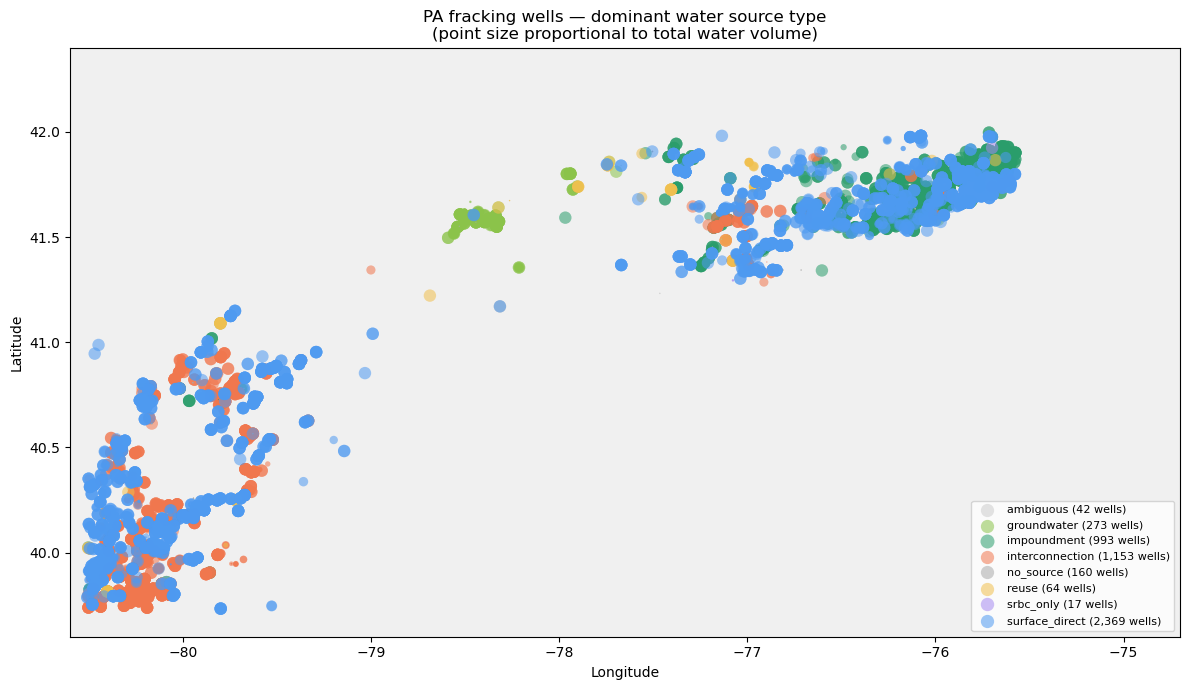

Wells plotted: 5,071


In [7]:
# Pull well coordinates from skinny_df (not stored in junction parquet)
well_coords = (
    pd.read_parquet(SKINNY_PATH, columns=['api10', 'bgLatitude', 'bgLongitude'])
    .groupby('api10', as_index=False)
    .first()
    .rename(columns={'bgLatitude': 'well_lat', 'bgLongitude': 'well_lon'})
)

# One row per well: dominant source type by volume
well_summary = (
    jct.merge(well_coords, on='api10', how='left')
    .groupby('api10')
    .apply(lambda g: pd.Series({
        'well_lat':    g['well_lat'].iloc[0],
        'well_lon':    g['well_lon'].iloc[0],
        'total_vol':   g['volume'].sum(),
        'dom_type':    g.groupby('source_type')['volume'].sum().idxmax(),
        'pct_surface': g.loc[g['source_type'].isin(
            ['surface_direct','impoundment','srbc_only']), 'volume'].sum()
                      / g['volume'].sum() * 100,
    }))
    .reset_index()
    .dropna(subset=['well_lat','well_lon'])
)

fig, ax = plt.subplots(figsize=(12, 7))

type_colors = {
    'surface_direct':  '#4e9af1',
    'impoundment':     '#2a9d6b',
    'srbc_only':       '#a78af1',
    'reuse':           '#f1c04e',
    'interconnection': '#f1774e',
    'groundwater':     '#8bc34a',
    'dont_know':       '#999',
    'ambiguous':       '#ccc',
}

for dtype, grp in well_summary.groupby('dom_type'):
    ax.scatter(
        grp['well_lon'], grp['well_lat'],
        s=np.clip(grp['total_vol'] / 1e5, 1, 80),
        c=type_colors.get(dtype, '#aaa'),
        alpha=0.55, linewidths=0,
        label=f'{dtype} ({len(grp):,} wells)'
    )

ax.set_xlim(-80.6, -74.7)
ax.set_ylim(39.6, 42.4)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('PA fracking wells — dominant water source type\n(point size proportional to total water volume)')
ax.legend(loc='lower right', fontsize=8, markerscale=1.5)
ax.set_facecolor('#f0f0f0')
plt.tight_layout()
plt.savefig('figures/well_map.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Wells plotted: {len(well_summary):,}')

## 6. Reuse trend — fraction of water volume recycled by year

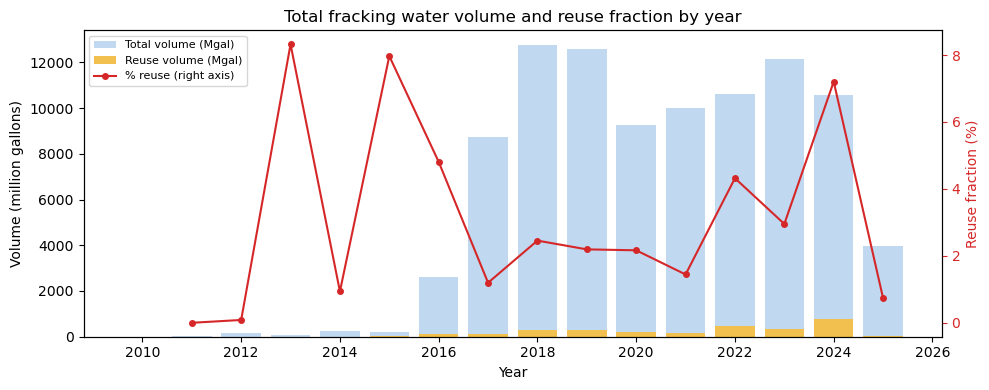

  year  total_Mgal  reuse_Mgal  pct_reuse
2010.0         0.0         0.0        NaN
2011.0        15.4         0.0        0.0
2012.0       153.9         0.1        0.1
2013.0        84.4         7.0        8.3
2014.0       239.8         2.3        0.9
2015.0       206.0        16.4        8.0
2016.0      2594.2       124.8        4.8
2017.0      8739.9       104.6        1.2
2018.0     12760.7       313.4        2.5
2019.0     12564.6       275.6        2.2
2020.0      9239.0       200.1        2.2
2021.0     10023.8       144.7        1.4
2022.0     10628.7       459.1        4.3
2023.0     12159.1       359.1        3.0
2024.0     10558.6       760.8        7.2
2025.0      3962.8        29.1        0.7


In [8]:
reuse_trend = (
    valid_yr.groupby('year')
    .apply(lambda g: pd.Series({
        'total_Mgal':  g['volume'].sum() / 1e6,
        'reuse_Mgal':  g.loc[g['source_type'] == 'reuse', 'volume'].sum() / 1e6,
        'pct_reuse':   g.loc[g['source_type'] == 'reuse', 'volume'].sum()
                       / g['volume'].sum() * 100,
    }))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(reuse_trend['year'], reuse_trend['total_Mgal'],
        color='#c0d8f0', label='Total volume (Mgal)')
ax1.bar(reuse_trend['year'], reuse_trend['reuse_Mgal'],
        color='#f1c04e', label='Reuse volume (Mgal)')
ax2.plot(reuse_trend['year'], reuse_trend['pct_reuse'],
         color='#d62728', marker='o', ms=4, label='% reuse (right axis)')

ax1.set_xlabel('Year')
ax1.set_ylabel('Volume (million gallons)')
ax2.set_ylabel('Reuse fraction (%)', color='#d62728')
ax2.tick_params(axis='y', colors='#d62728')
ax1.set_title('Total fracking water volume and reuse fraction by year')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('figures/reuse_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(reuse_trend[['year','total_Mgal','reuse_Mgal','pct_reuse']].round(1).to_string(index=False))

## 7. Surface water: volume by major river basin
Approximate basin assignment from well longitude — PA's major drainages run roughly N-S.

Surface water volume by major basin (high/good matches):
                records  volume_Mgal   pct
basin                                     
Ohio/Allegheny     1522      11743.8  33.2
Susquehanna        6221       9986.1  28.3
Unknown/Other      4176       7830.6  22.2
Monongahela         773       5682.9  16.1
Genesee/NY           19         97.7   0.3


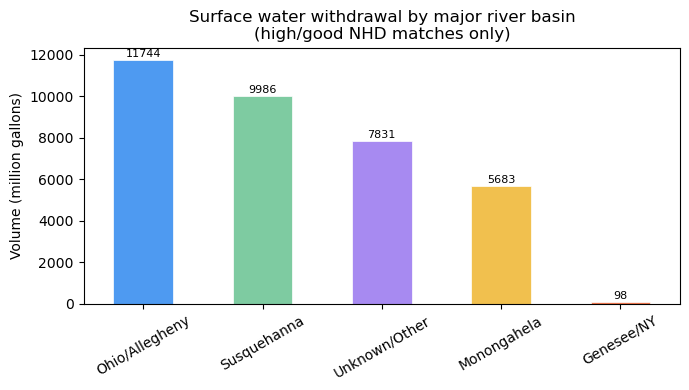

In [9]:
# Use NHD name to group by major basin (manual lookup for top features)
BASIN_MAP = {
    'Susquehanna':   r'susquehanna|wyoming|tunkhannock|loyalsock|lycoming|'   
                     r'bald eagle|west branch|juniata|penns|fishing|pine|'   
                     r'loyalhanna|conestoga|codorus|swatara',
    'Monongahela':   r'monongahela|dunkard|ten mile|tenmile|chestnut|'   
                     r'youghiogheny|yough|sewickley|little sewickley',
    'Ohio/Allegheny':r'allegheny|ohio|connoquenessing|buffalo|brush|'   
                     r'sandy|thorn|beaver|shenango|crooked|little beaver|'   
                     r'neshannock|slippery',
    'Delaware':      r'delaware|lehigh|brodhead',
    'Genesee/NY':    r'genesee|tioga|chemung',
}

def assign_basin(nhd_name):
    if pd.isna(nhd_name): return 'Unknown/Other'
    n = nhd_name.lower()
    for basin, pat in BASIN_MAP.items():
        if pd.notna(n) and pd.Series([n]).str.contains(pat, case=False, regex=True).iloc[0]:
            return basin
    return 'Unknown/Other'

surface_linked = jct[
    jct['source_type'].isin(['surface_direct','srbc_only']) &
    jct['match_tier'].isin(['high (>=90)', 'good (80-89)'])
].copy()
surface_linked['basin'] = surface_linked['nhd_name'].apply(assign_basin)

basin_vol = (
    surface_linked.groupby('basin')['volume']
    .agg(records='count', volume_gal='sum')
    .assign(
        volume_Mgal = lambda d: (d['volume_gal'] / 1e6).round(1),
        pct         = lambda d: (d['volume_gal'] / d['volume_gal'].sum() * 100).round(1),
    )
    .sort_values('volume_gal', ascending=False)
)
print('Surface water volume by major basin (high/good matches):')
print(basin_vol[['records','volume_Mgal','pct']].to_string())

fig, ax = plt.subplots(figsize=(7, 4))
basin_colors = ['#4e9af1','#7ecba1','#a78af1','#f1c04e','#f1774e','#bbb']
basin_vol['volume_Mgal'].plot.bar(ax=ax, color=basin_colors[:len(basin_vol)],
                                   edgecolor='white', linewidth=0.5)
ax.set_xlabel('')
ax.set_ylabel('Volume (million gallons)')
ax.set_title('Surface water withdrawal by major river basin\n(high/good NHD matches only)')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(ax.patches, basin_vol['volume_Mgal']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('figures/vol_by_basin.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Residual ambiguous sources and low-confidence NHD matches
`dont_know` has been fully resolved via PA DEP water resource matching and manual curation.
Remaining gaps: `ambiguous` (0.2% of volume) and fair/low NHD matches.

In [10]:
# DEP reclassification summary
dep_matched = jct[jct['dep_score'].notna() & (jct['dep_score'] >= 80)]
dep_coords = jct[jct['dep_lat'].notna()]
print('=== DEP matching coverage ===')
print(f'Junction rows with dep_score >= 80:  {len(dep_matched):,}  ({len(dep_matched)/len(jct)*100:.1f}%)')
print(f'Junction rows with DEP coordinates:  {len(dep_coords):,}  ({len(dep_coords)/len(jct)*100:.1f}%)')
print()

# Previously dont_know — now resolved
was_dk_types = jct[jct['dep_src'].notna() & jct['planSource'].str.contains(
    r'\b(SWW|WI|SPWA|SWPA|Aqua|MAWC|MANK|NKWA|Clermont|AWS)\b', case=False, na=False
)].groupby('source_type')['volume'].sum() / 1e6
print('Volume (Mgal) of formerly-dont_know patterns by resolved type:')
for st, v in was_dk_types.sort_values(ascending=False).items():
    print(f'  {st:20s}  {v:,.1f}')
print()

# Remaining ambiguous
amb = jct[jct['source_type'] == 'ambiguous']
print(f'Remaining ambiguous: {amb["planSource"].nunique()} unique sources, '
      f'{amb["volume"].sum()/1e6:.1f} Mgal ({amb["volume"].sum()/jct["volume"].sum()*100:.2f}% of total)')

=== DEP matching coverage ===
Junction rows with dep_score >= 80:  28,198  (57.1%)
Junction rows with DEP coordinates:  28,198  (57.1%)

Volume (Mgal) of formerly-dont_know patterns by resolved type:
  interconnection       11,336.9
  surface_direct        8,206.9
  groundwater           1,230.2
  impoundment           771.0

Remaining ambiguous: 88 unique sources, 153.7 Mgal (0.15% of total)


In [11]:
# Remaining ambiguous bucket — top sources
amb = jct[jct['source_type'] == 'ambiguous']
amb_top = (
    amb.groupby('planSource')['volume']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    / 1e6
).round(2)
print(f'ambiguous bucket: {amb["planSource"].nunique()} unique sources, '
      f'{amb["volume"].sum()/1e6:.1f} Mgal total')
print()
print('Top 30 ambiguous sources by volume (Mgal):')
print(amb_top.to_string())

ambiguous bucket: 88 unique sources, 153.7 Mgal total

Top 30 ambiguous sources by volume (Mgal):
planSource
ODELL                                              21.08
FRS                                                15.49
EASTERN REAGION WMP #269846-04 MESSHOPPEN CROOK     9.51
LDG Water Draw                                      8.61
STUNNER / SMITH                                     8.43
RES Butler                                          8.15
YOUNG EXTRACTION                                    7.75
Laurel Mountain                                     7.17
Limbach Lane                                        7.00
Shell                                               6.50
WB-3                                                6.45
Fox Whitney Drive                                   5.00
Greylock Genesee Forks (SRBC 20240311)              4.71
B&B INVESTMENT GRP                                  4.25
Montoursville Borough                               4.09
SRC5H                               

In [12]:
# Fair/low NHD matches — candidates where we have a match but low confidence
low_conf = jct[
    jct['match_tier'].isin(['fair (60-79)', 'low (<60)']) &
    jct['nhd_name'].notna()
]
low_by_source = (
    low_conf.groupby(['planSource','nhd_name','score'])
    .agg(volume_Mgal=('volume', lambda x: round(x.sum()/1e6, 2)))
    .reset_index()
    .sort_values('volume_Mgal', ascending=False)
    .head(30)
)
print('Top fair/low-confidence matches by volume:')
print(low_by_source.to_string(index=False))

Top fair/low-confidence matches by volume:
                                                             planSource                     nhd_name     score  volume_Mgal
                                            North Fork of Dunkard Creek       North Fork Short Creek 73.469388       786.47
                                                     Mon River - Tuna 1                   Ohio River 73.684211       767.82
                                        Mon River (Luzerne) - Source 47                  Shriver Run 70.000000       608.89
                                               North Fork Dunkard Creek      North Fork Dunkard Fork 76.595745       562.75
                                                            Lake Oneida                    Lake Lucy 61.538462       397.99
                             Fall Brook Creek (DCNR), Docket # 20180303                   Fall Brook 76.923077       347.92
                  Bailey Freshwater Pond (Richhill Twp./Greene Co.) #47           Fork of

## 9. Summary table — NHD-linked features for export

In [13]:
import os
os.makedirs('figures', exist_ok=True)

# Per-NHD-feature summary: high+good only
nhd_summary = (
    jct[
        jct['match_tier'].isin(['high (>=90)', 'good (80-89)']) &
        jct['nhd_name'].notna()
    ]
    .groupby(['nhd_id', 'nhd_name', 'nhd_ftype', 'nhd_layer'])
    .agg(
        unique_sources  = ('planSource', 'nunique'),
        unique_wells    = ('api10', 'nunique'),
        volume_Mgal     = ('volume', lambda x: round(x.sum() / 1e6, 2)),
        median_score    = ('score', 'median'),
        median_dist_km  = ('dist_km', 'median'),
    )
    .reset_index()
    .sort_values('volume_Mgal', ascending=False)
)

print(f'NHD features with linked volume (high/good): {len(nhd_summary):,}')
print(f'Total volume: {nhd_summary["volume_Mgal"].sum():,.0f} Mgal')
print()
print(nhd_summary.head(40).to_string(index=False))

nhd_summary.to_csv('data/nhd_feature_volume_summary.csv', index=False)
print('\nSaved: data/nhd_feature_volume_summary.csv')

NHD features with linked volume (high/good): 133
Total volume: 41,481 Mgal

   nhd_id                    nhd_name  nhd_ftype nhd_layer  unique_sources  unique_wells  volume_Mgal  median_score  median_dist_km
 66392615           Tunkhannock Creek      460.0  flowline              56           596      3897.87    100.000000            27.9
123862354             Allegheny River      558.0  flowline              17           122      3536.02    100.000000             5.9
 66404293             Meshoppen Creek      558.0  flowline              83           645      2931.77    100.000000             8.2
 99686060                  Ohio River      558.0  flowline              11           292      2739.33    100.000000            26.5
 43482891           Susquehanna River      558.0  flowline              45           546      2452.27    100.000000            49.5
 99412026           Monongahela River      558.0  flowline              33           222      1768.32    100.000000            15.2
